suavizado de punto de interes

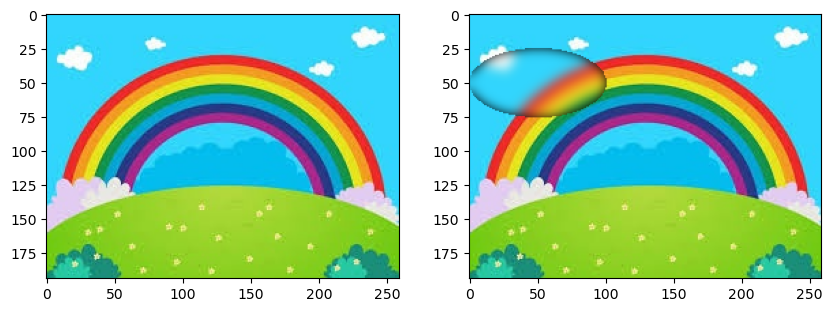

In [2]:
import cv2
import numpy as np 
import matplotlib.pyplot as plt

def desenfoque(img, centro,x,y):
    img1=np.copy(img)
    valx,valy=centro
    mediox=x//2
    medioy=y//2
    mascara=np.zeros_like(img,dtype=np.uint8)
    cv2.ellipse(mascara,(valx,valy),(mediox,medioy),0,0,360,(255,255,255),-1)
    img_mask=cv2.bitwise_and(img,mascara)
    desenfoque=cv2.GaussianBlur(img_mask,(25,25),0)
    img1[mascara!=0]=desenfoque[mascara!=0]
    return img1
imagen=cv2.imread('image.png')
imagenrgb=cv2.cvtColor(imagen,cv2.COLOR_BGR2RGB)
img_desenfoque=desenfoque(imagenrgb,(50,50),100,50)
plt.figure(figsize=(10,5))
plt.subplot(121)
plt.imshow(imagenrgb)
plt.subplot(122)
plt.imshow(img_desenfoque)

plt.show()


C:\Users\ASUS Vivobook\AppData\Local\Temp\ipykernel_21844\1997601473.py:27: RuntimeWarning: invalid value encountered in sqrt
  prew_mag = np.sqrt(prewittx*2+prewitty*2)
C:\Users\ASUS Vivobook\AppData\Local\Temp\ipykernel_21844\1997601473.py:38: RuntimeWarning: invalid value encountered in sqrt
  sob_mag = np.sqrt(sobelx*2+sobely*2)


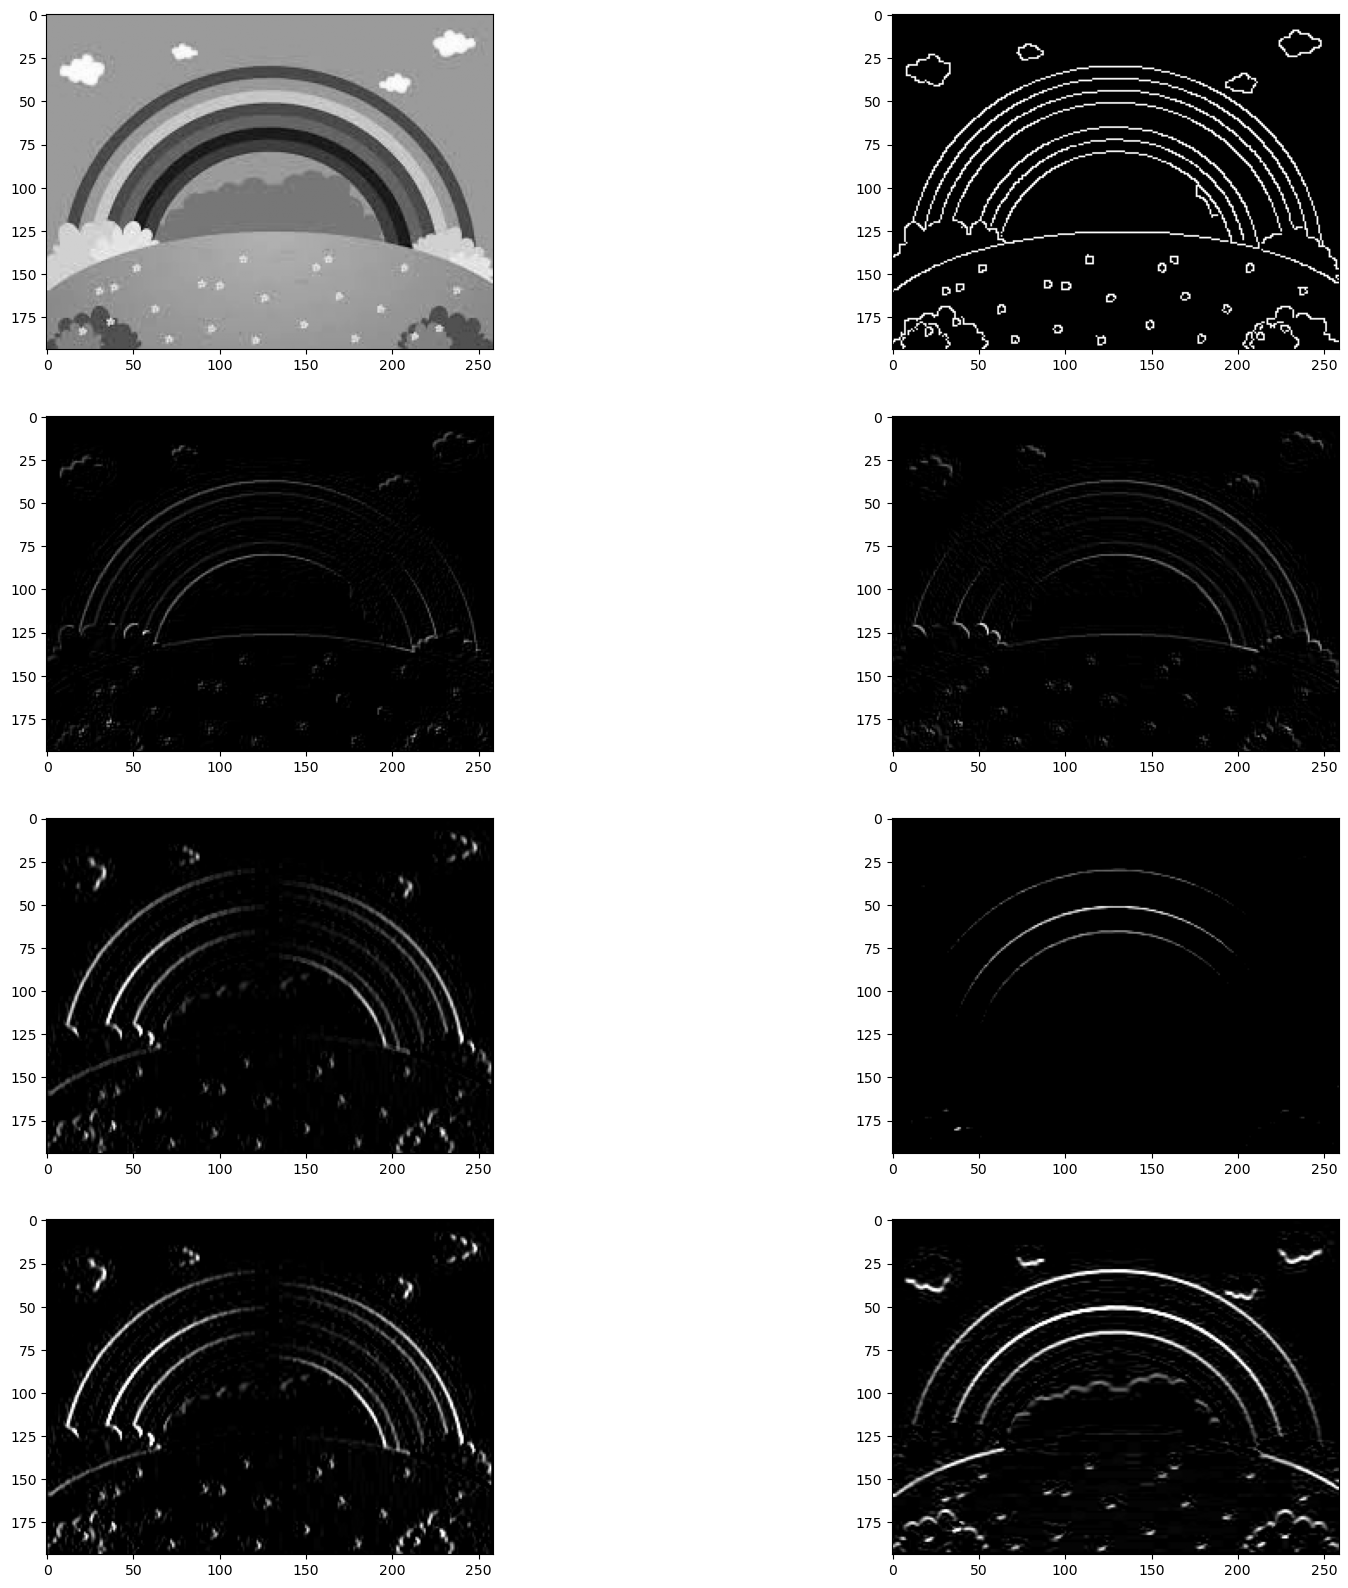

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imgo1 = cv2.imread("image.png")
imggray = cv2.cvtColor(imgo1,cv2.COLOR_BGR2GRAY)

# filtro Roberts
# Kernel 
robertsx = np.array([[-1,0],[0,1]])
robertsy = np.array([[0,-1],[1,0]])

img_robx = cv2.filter2D(imggray, -1, robertsx)
img_roby = cv2.filter2D(imggray, -1, robertsy)

rob_gmagnitud = np.sqrt(img_robx*2+img_roby*2)
rob_gsireccion = np.arctan2(img_roby,img_robx) # Simulando aplicar un filtro prewitt

# filstro prewitt
# kernels
prewittx = np.array([[1,0,-1],[1,0,-1],[1,0,-1]])
prewitty = np.array([[1,1,0],[0,0,0],[-1,-1,-1]])

img_prx = cv2.filter2D(imggray, -1, prewittx)
img_pry = cv2.filter2D(imggray, -1, prewitty)

prew_mag = np.sqrt(prewittx*2+prewitty*2)
prew_dir = np.arctan2(prewitty,prewittx)

# filtro sobel
# kernel
sobelx = np.array([[1,0,-1],[2,0,-2],[1,0,-1]])
sobely = np.array([[1,2,1],[0,0,0],[-1,-2,-1]])

img_sobx = cv2.filter2D(imggray, -1, sobelx)
img_soby = cv2.filter2D(imggray, -1, sobely)

sob_mag = np.sqrt(sobelx*2+sobely*2)
sob_dir = np.arctan2(sobely,sobelx)

# filtro Canny
canny = cv2.Canny(imggray, 100,200)

fig,axs = plt.subplots(4,2,figsize=(20,20))

axs[0][0].imshow(imggray, cmap="gray")
axs[0][1].imshow(canny, cmap="gray")
axs[1][0].imshow(img_robx, cmap="gray")
axs[1][1].imshow(img_roby, cmap="gray")
axs[2][0].imshow(img_prx, cmap="gray")
axs[2][1].imshow(img_pry, cmap="gray")
axs[3][0].imshow(img_sobx, cmap="gray")
axs[3][1].imshow(img_soby, cmap="gray")

ROBERTS

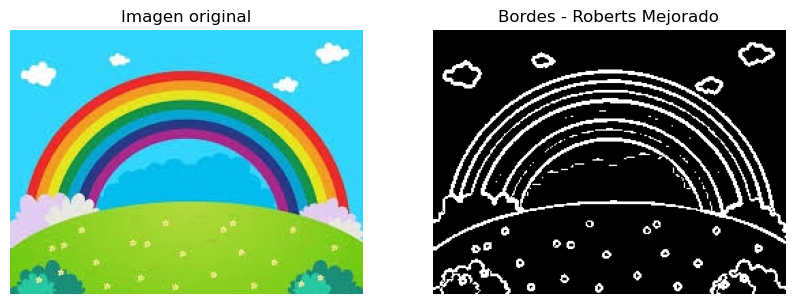

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def roberts_mejorado(imagen):
    img_gray = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)

    suavizado = cv2.GaussianBlur(img_gray, (3, 3), 0)

    kernelx = np.array([[-2, 0], [0, 2]], dtype=np.float32)
    kernely = np.array([[0, 2], [-2, 0]], dtype=np.float32)

    robx = cv2.filter2D(suavizado, cv2.CV_16S, kernelx)
    roby = cv2.filter2D(suavizado, cv2.CV_16S, kernely)

    roberts = cv2.addWeighted(np.abs(robx), 0.7, np.abs(roby), 0.7, 0)

    _, bordes = cv2.threshold(roberts, 30, 255, cv2.THRESH_BINARY)

    return bordes

imagen = cv2.imread('image.png')

bordes = roberts_mejorado(imagen)

plt.figure(figsize=(10, 5))
plt.subplot(121)
plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
plt.title("Imagen original")
plt.axis('off')

plt.subplot(122)
plt.imshow(bordes, cmap='gray')
plt.title("Bordes - Roberts Mejorado")
plt.axis('off')

plt.show()


sobel mejorado

C:\Users\ASUS Vivobook\AppData\Local\Temp\ipykernel_21844\785428003.py:12: RuntimeWarning: invalid value encountered in sqrt
  magnitud=np.sqrt(sobelx**2+sobely**2)


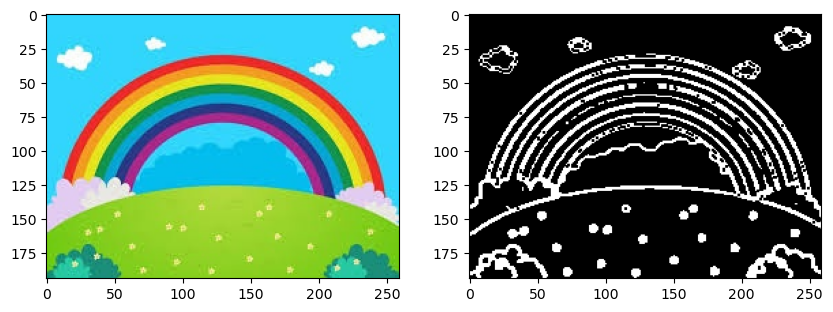

In [35]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def sobel_mejor(imagen, tam_kernel=3,umbral=30):
    img_gray=cv2.cvtColor(imagen,cv2.COLOR_BGR2GRAY)
    img_gray=cv2.GaussianBlur(img_gray,(3,3),0)

    sobelx=cv2.Sobel(img_gray,cv2.CV_16S,1,0,ksize=tam_kernel)
    sobely=cv2.Sobel(img_gray,cv2.CV_16S,0,1,ksize=tam_kernel)

    magnitud=np.sqrt(sobelx**2+sobely**2)

    magnitud=cv2.normalize(magnitud,None,0,255,cv2.NORM_MINMAX,cv2.CV_8U)
    _,bordes=cv2.threshold(magnitud,umbral,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)#AGREGARIAMOS OTSU
    #UNIR BORDES ROTOS
    ketnel_morf=np.ones((2,2),np.uint8)
    bordes=cv2.morphologyEx(bordes,cv2.MORPH_CLOSE,ketnel_morf)
    return bordes

imagen = cv2.imread('image.png')
bordes = sobel_mejor(imagen)

plt.figure(figsize=(10, 5))
plt.subplot(121)
plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
plt.subplot(122)
plt.imshow(bordes, cmap='gray')
plt.show()


PREWITT MEJORADO

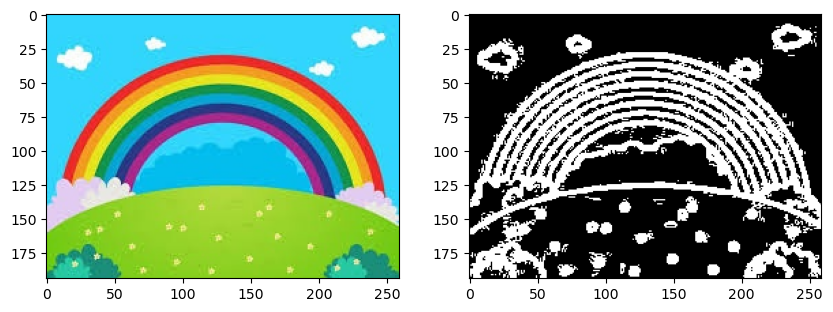

In [30]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def prewitt_mejor(imagen):
    img_gray=cv2.cvtColor(imagen,cv2.COLOR_BGR2GRAY)
    img_gray=cv2.GaussianBlur(img_gray,(3,3),0)

    prewittx = np.array([[3, 0,-3], [3,0,-3],[3,0,-3]], dtype=np.float32)
    prewitty = np.array([[3,3,3], [0,0,0],[-3,-3,-3]], dtype=np.float32)

    x = cv2.filter2D(img_gray, cv2.CV_64F, prewittx)
    y = cv2.filter2D(img_gray, cv2.CV_64F, prewitty)

    magnitud=np.sqrt(x**2+y**2)

    _,bordes=cv2.threshold(magnitud,30,255,cv2.THRESH_BINARY)
    
    return bordes

imagen = cv2.imread('image.png')
bordes = prewitt_mejor(imagen)

plt.figure(figsize=(10, 5))
plt.subplot(121)
plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
plt.subplot(122)
plt.imshow(bordes, cmap='gray')
plt.show()

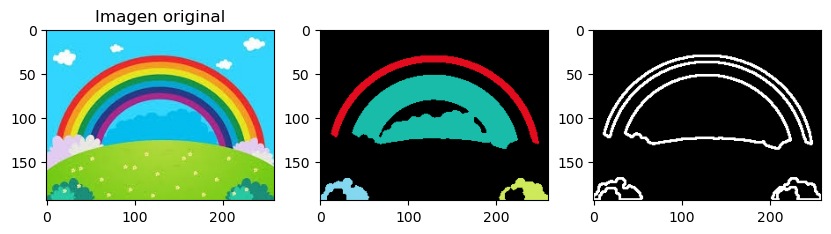

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imagen=cv2.imread('image.png')
gray = cv2.cvtColor(imagen,cv2.COLOR_BGR2GRAY)
blur =cv2.GaussianBlur(gray,(7,7),0)
_,binarizada=cv2.threshold(blur,0,255,cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU)

#regiones
cant,region=cv2.connectedComponents(binarizada)
colores=np.random.randint(0,255,size=(cant,3),dtype=np.uint8)
colores[0]=[0,0,0]
color_region=colores[region]

#fdronteras
contorno,_=cv2.findContours(binarizada,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
linea=cv2.drawContours(np.zeros_like(gray),contorno,-1,255,2)


plt.figure(figsize=(10, 5))
plt.subplot(131)
plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
plt.title("Imagen original")


plt.subplot(132)
plt.imshow(color_region)



plt.subplot(133)
plt.imshow(linea, cmap='gray')
plt.tight_layout

plt.show()

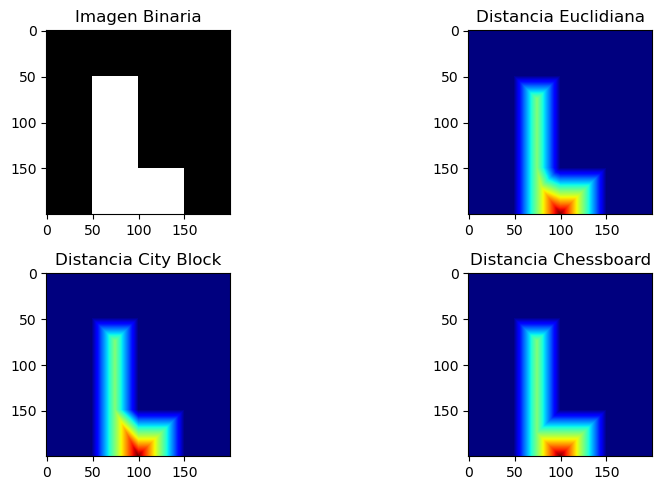

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


img = np.zeros((200, 200), dtype=np.uint8)
img[50:150, 50:100] = 1
img[150:200, 50:150] = 1

img_binarizada = img.astype(np.uint8) * 255


def distancia(img_binarizada):
    # Euclidiana
    dist_eucli = cv2.distanceTransform(img_binarizada, cv2.DIST_L2, 3)
    # City block
    dist_city = cv2.distanceTransform(img_binarizada, cv2.DIST_L1, 3)
    # Chessboard
    dist_chess = cv2.distanceTransform(img_binarizada, cv2.DIST_C, 3)
    
    return dist_eucli, dist_city, dist_chess


eucl, city, chess = distancia(img_binarizada)


def normalizar(dist):
    return cv2.normalize(dist, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)


normeucl = normalizar(eucl)
normcity = normalizar(city)
normchess = normalizar(chess)


plt.figure(figsize=(10, 5))

plt.subplot(2, 2, 1)
plt.imshow(img, cmap='gray')
plt.title("Imagen Binaria")

plt.subplot(2, 2, 2)
plt.imshow(normeucl, cmap='jet')
plt.title("Distancia Euclidiana")

plt.subplot(2, 2, 3)
plt.imshow(normcity, cmap='jet')
plt.title("Distancia City Block")

plt.subplot(2, 2, 4)
plt.imshow(normchess, cmap='jet')
plt.title("Distancia Chessboard")

plt.tight_layout()
plt.show()

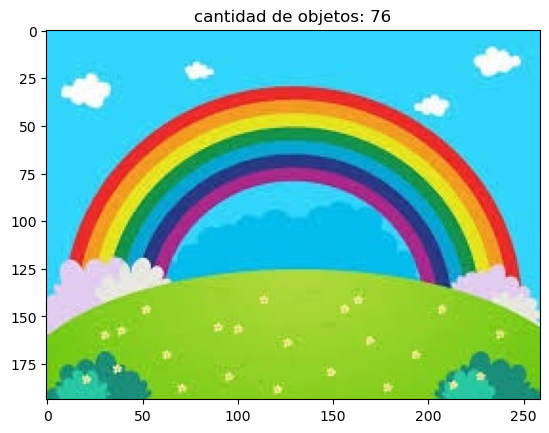

In [1]:
import cv2 
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure

#conda activate "entorno_pdi"
#conda install scikit-image

def contar(imagen):
    gray=cv2.cvtColor(imagen,cv2.COLOR_BGR2GRAY)
    _,bianrizar=cv2.threshold(gray,127,255,cv2.THRESH_BINARY)
    etiquetar=measure.label(bianrizar,connectivity=2)#conectividad con 4 == 2 y conectividad de 8 == 1
    num=np.max(etiquetar)
    return num


imagen=cv2.imread('image.png')
contarr=contar(imagen)

plt.imshow(cv2.cvtColor(imagen,cv2.COLOR_BGR2RGB))
plt.title(f'cantidad de objetos: {contarr}')
plt.show()

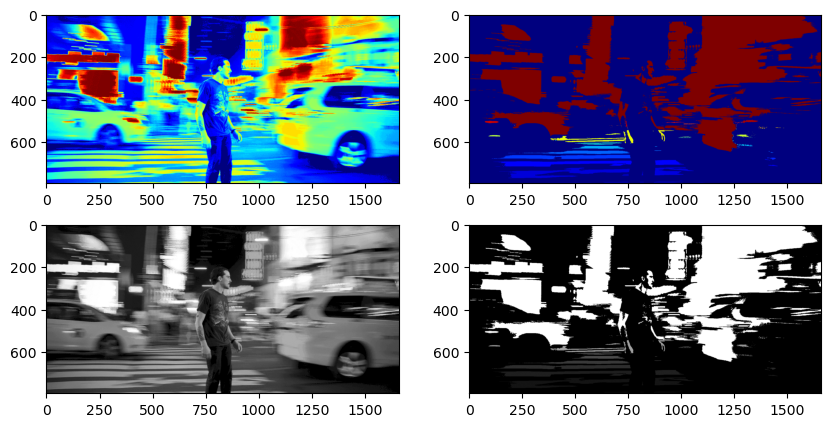

In [5]:
import cv2 
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure

def etiquetar(img):
    #umbralizado
    _,imgBIN=cv2.threshold(img,127,255,cv2.THRESH_BINARY)
    #encontrar los entornos
    contorno,_=cv2.findContours(imgBIN,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
    img_etiq=np.zeros_like(img,dtype=np.uint8)
    for i,contornoss in enumerate(contorno):
        cv2.drawContours(img_etiq,[contornoss],-1,(i+1),-1)
    return img_etiq

imagen=cv2.imread('img2.png',0)
imagen_etiqueta=etiquetar(imagen)
plt.figure(figsize=(10,5))
plt.subplot(221)
plt.imshow(imagen,cmap='jet')

plt.subplot(222)
plt.imshow(imagen_etiqueta,cmap='jet')

plt.subplot(223)
plt.imshow(imagen,cmap='gray')

plt.subplot(224)
plt.imshow(imagen_etiqueta,cmap='gray')

plt.show()

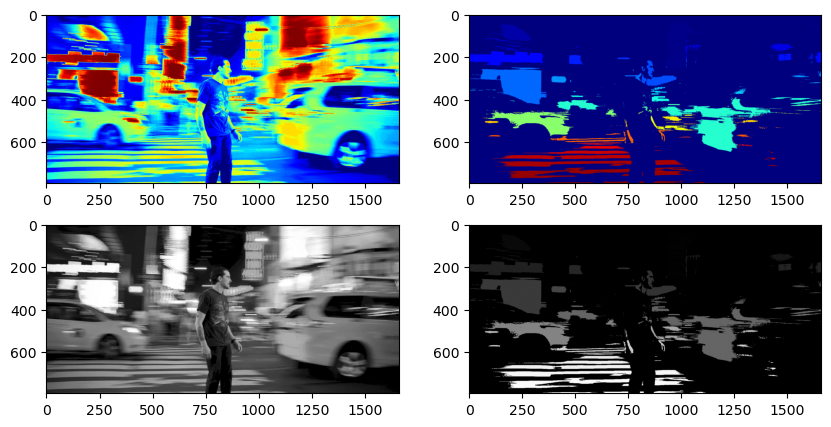

In [6]:
import cv2 
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure

img_gray=cv2.imread('img2.png',0)
_,imgbin=cv2.threshold(img_gray,127,255,cv2.THRESH_BINARY)
img_etiq=measure.label(imgbin,connectivity=1)

plt.figure(figsize=(10,5))
plt.subplot(221)
plt.imshow(img_gray,cmap='jet')

plt.subplot(222)
plt.imshow(img_etiq,cmap='jet')

plt.subplot(223)
plt.imshow(img_gray,cmap='gray')

plt.subplot(224)
plt.imshow(img_etiq,cmap='gray')

plt.show()


CONTEO

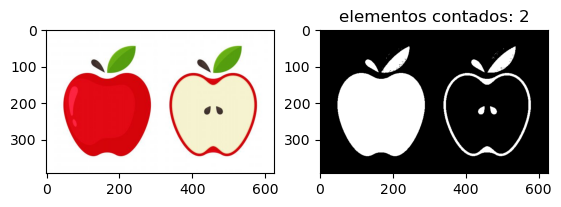

In [ ]:
import cv2 
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure

def conteo(img):
    img_gray=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
    _,binaria=cv2.threshold(img_gray,127,255,cv2.THRESH_BINARY_INV)
    borde=cv2.findContours(binaria,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
    cont=len(borde)
    return cont, binaria
imagen=cv2.imread('manzanas.jpg')
img_cont,bin=conteo(imagen)
plt.figure(figsize=(10,5))
plt.subplot(231)
plt.imshow(cv2.cvtColor(imagen,cv2.COLOR_BGR2RGB))

plt.subplot(232)
plt.title(f'elementos contados: {img_cont}')
plt.imshow(bin,cmap='gray')

plt.show()


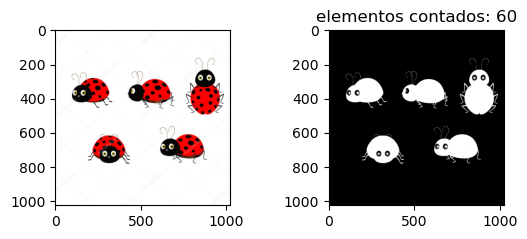

In [10]:
import cv2 
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure

def conteo2(imge):
    img_gray=cv2.cvtColor(imge,cv2.COLOR_BGR2GRAY)
    _,binarizada=cv2.threshold(img_gray,127,255,cv2.THRESH_BINARY_INV)
    contorno=measure.label(binarizada,connectivity=2)
    cont=np.max(contorno)
    return cont, binarizada
imagen=cv2.imread('mariquitas.jpg')
contado,bin=conteo2(imagen)
plt.figure(figsize=(10,5))
plt.subplot(231)
plt.imshow(cv2.cvtColor(imagen,cv2.COLOR_BGR2RGB))

plt.subplot(232)
plt.title(f'elementos contados: {contado}')
plt.imshow(bin,cmap='gray')

plt.show()
